# PI Etancheite - Notebook Pas a Pas (Nettoye)

Ce notebook reprend le workflow complet de calibration laser -> HA en etapes claires.

Il peut maintenant etre pointe soit vers l'ancien jeu `Mesures27062024`, soit vers le nouveau jeu `data/raw/calibration` via la cellule de configuration.


In [13]:
# [Guide] Cellule de configuration globale du notebook.
# - Importe les libs
# - Configure Matplotlib (inline en notebook)
# - Définit les chemins d'entrée/sortie
# - Choisit le dataset a tester

from __future__ import annotations

import os
import re
import sys
from pathlib import Path
from zipfile import ZipFile
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd

import matplotlib
try:
    from IPython import get_ipython
except Exception:
    get_ipython = None

ip = get_ipython() if get_ipython else None
if ip is not None:
    # Notebook session: inline rendering
    matplotlib.use('module://matplotlib_inline.backend_inline', force=True)
else:
    # Script/headless fallback
    os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
    os.environ.setdefault('XDG_CACHE_HOME', '/tmp')
    matplotlib.use('Agg')

import matplotlib.pyplot as plt

# Affichage pandas
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

# Rend l'import `src.analysis...` robuste meme si le notebook est lance depuis `notebooks/`
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'src').exists() and (REPO_ROOT.parent / 'src').exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATASET_NAME = 'current_calibration'  # 'legacy_20240627' ou 'current_calibration'

if DATASET_NAME == 'legacy_20240627':
    DATA_DIR = REPO_ROOT / 'data/raw/Mesures27062024'
    BUTTON_PATH = DATA_DIR / 'HYGROBOUTON_LOCLE_DAS.xlsx'
    SUMMARY_PATH = DATA_DIR / 'Calibration27062024_summary.txt'
    SIGNAL_PATTERN = 'Mesures27062024_*.txt'
else:
    DATA_DIR = REPO_ROOT / 'data/raw/calibration'
    BUTTON_PATH = DATA_DIR / 'button-test-1.xls'
    SUMMARY_PATH = None
    SIGNAL_PATTERN = '*_calibration_*.txt'

OUT_FIG_DIR = REPO_ROOT / 'outputs/figures/calibration'
OUT_REP_DIR = REPO_ROOT / 'outputs/reports'
OUT_FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_REP_DIR.mkdir(parents=True, exist_ok=True)


def parse_scan_datetime_from_name(path: Path) -> pd.Timestamp | pd.NaT:
    """Extrait un timestamp depuis un nom du type YYYYMMDD_HHMMSS_..."""
    m = re.match(r'^(\d{8}_\d{6})_', path.stem)
    if not m:
        return pd.NaT
    try:
        return pd.to_datetime(m.group(1), format='%Y%m%d_%H%M%S')
    except Exception:
        return pd.NaT


def parse_trailing_int(stem: str) -> int | None:
    """Extrait le dernier entier d'un stem si present."""
    m = re.search(r'(\d+)$', stem)
    return int(m.group(1)) if m else None


def signal_sort_key(path: Path) -> tuple:
    """Tri robuste: timestamp si present, sinon entier final, sinon nom."""
    scan_dt = parse_scan_datetime_from_name(path)
    tail_num = parse_trailing_int(path.stem)
    if pd.notna(scan_dt):
        return (0, scan_dt.to_pydatetime(), tail_num if tail_num is not None else -1, path.name)
    if tail_num is not None:
        return (1, tail_num, path.name)
    return (2, path.name)


available_signals = sorted(DATA_DIR.glob(SIGNAL_PATTERN), key=signal_sort_key)
if not available_signals:
    raise FileNotFoundError(f'No signal found under {DATA_DIR} with {SIGNAL_PATTERN}')

EXAMPLE_PATH = available_signals[min(0, len(available_signals) - 1)]

print('REPO_ROOT =', REPO_ROOT)
print('DATASET_NAME =', DATASET_NAME)
print('DATA_DIR =', DATA_DIR)
print('BUTTON_PATH exists =', BUTTON_PATH.exists())
print('SUMMARY_PATH =', SUMMARY_PATH)
print('N signals =', len(available_signals))
print('Example signal =', EXAMPLE_PATH.name)
print('matplotlib backend =', matplotlib.get_backend())


REPO_ROOT = /Users/valonmehmeti/hesso/PI
DATASET_NAME = current_calibration
DATA_DIR = /Users/valonmehmeti/hesso/PI/data/raw/calibration
BUTTON_PATH exists = True
SUMMARY_PATH = None
N signals = 1200
Example signal = 20260511_211415_calibration_1.txt
matplotlib backend = module://matplotlib_inline.backend_inline


## 1) Lecture et visualisation d'un scan brut

/Users/valonmehmeti/hesso/PI
Fichier: 20260511_211415_calibration_1.txt | N = 9200
min/max = -0.735605 0.755747


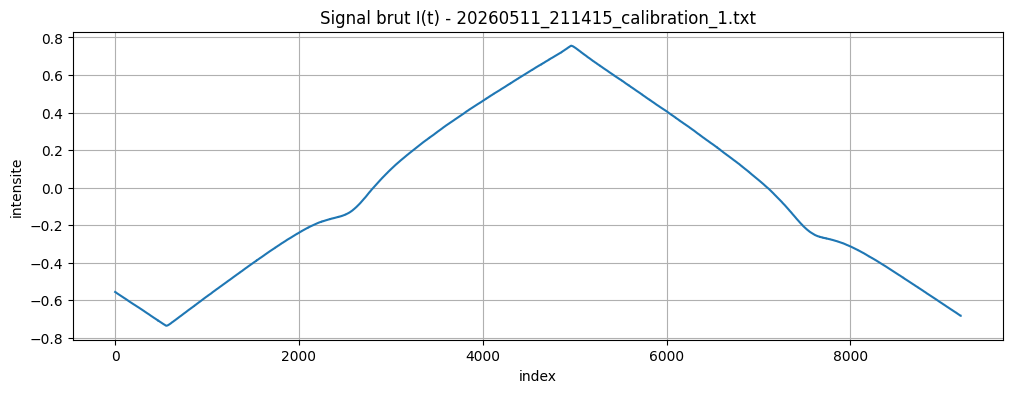

In [14]:
# [Guide] Étape 1: lecture d'un fichier laser brut et visualisation de I(t).

def read_signal(path: Path) -> np.ndarray:
    """Lit un scan .txt et renvoie l'intensité I(t) en numpy array float."""
    values = []
    with path.open('r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            s = line.strip()
            if not s:
                continue
            try:
                values.append(float(s.replace(',', '.')))
            except ValueError:
                continue
    return np.array(values, dtype=float)

example_path = EXAMPLE_PATH
print(Path.cwd())
I = read_signal(example_path)
t = np.arange(I.size)

print('Fichier:', example_path.name, '| N =', I.size)
print('min/max =', float(I.min()), float(I.max()))

plt.figure(figsize=(12, 4))
plt.plot(t, I)
plt.title(f'Signal brut I(t) - {example_path.name}')
plt.xlabel('index')
plt.ylabel('intensite')
plt.grid(True)
plt.show()

# Evite la re-affichage de figures plus tard dans le notebook
plt.close('all')


## 2) Baseline `I0(t)` et absorbance `A(t)`

Méthode actuelle :
- détection du pic global `p = argmax(I)`
- détection de la zone utile principale entre les minima latéraux
- sélection de points "propres" par lissage léger
- fit de 2 droites (gauche / droite) sur cette zone utile
- jonction à l'intersection
- contrainte `I0 >= I`

Pour l'absorbance, le pipeline actuel applique aussi :
- un offset positif commun avant le `log`, pour éviter les pics artificiels quand le signal passe près de 0
- une limitation de `A(t)` à la zone utile interne, afin que les petits bouts parasites des bords ne polluent pas l'analyse


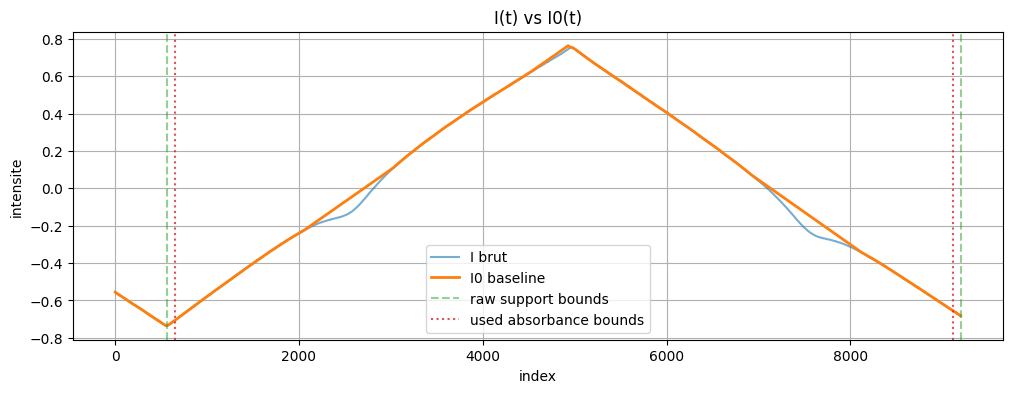

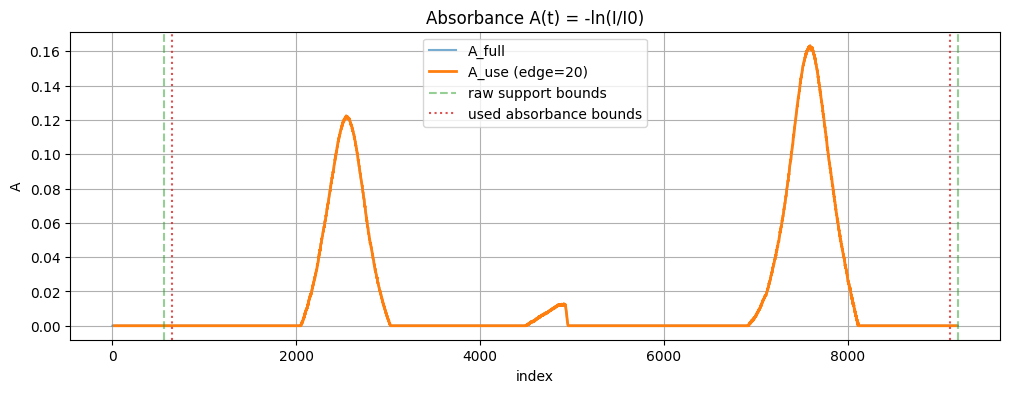

raw support bounds = 560 9199
used absorbance bounds = 646 9113
A_full min/max: -0.0 0.1632720505921793


In [15]:
# [Guide] Étape 2: construction de la baseline I0(t), puis calcul de A(t).

def moving_average_reflect(x: np.ndarray, window: int) -> np.ndarray:
    """Lissage simple avec padding miroir pour éviter les artefacts de bord."""
    if window % 2 == 0:
        raise ValueError('window must be odd')
    pad = window // 2
    x_pad = np.pad(x, pad_width=pad, mode='reflect')
    kernel = np.ones(window, dtype=float) / window
    return np.convolve(x_pad, kernel, mode='valid')


def detect_main_support(I: np.ndarray, peak_index: int | None = None, smooth_window: int = 101) -> tuple[int, int]:
    """Détecte la zone utile du triangle via les minima latéraux autour du pic principal."""
    if I.size < 3:
        return 0, max(0, I.size - 1)

    win = min(smooth_window, I.size if I.size % 2 == 1 else I.size - 1)
    if win < 3:
        win = 3 if I.size >= 3 else I.size
    if win % 2 == 0:
        win -= 1

    I_s = moving_average_reflect(I, win) if win >= 3 else I
    p = int(np.argmax(I_s if peak_index is None else I))
    if peak_index is not None:
        p = int(np.clip(peak_index, 1, I.size - 2))

    left_min = int(np.argmin(I_s[: p + 1]))
    right_min = int(p + np.argmin(I_s[p:]))
    left_min = max(0, min(left_min, p - 1))
    right_min = min(I.size - 1, max(right_min, p + 1))
    return left_min, right_min


def compute_I0(I: np.ndarray, smooth_window: int = 41, k: float = 0.20) -> np.ndarray:
    """Construit la baseline triangulaire I0(t) en ignorant les petits bouts parasites aux bords."""
    t = np.arange(I.size, dtype=float)
    p = int(np.argmax(I))
    left_bound, right_bound = detect_main_support(I, peak_index=p, smooth_window=101)

    I_s = moving_average_reflect(I, smooth_window)
    D = I_s - I
    thr = np.quantile(D, 1 - k)
    good = D < thr

    left = (t >= left_bound) & (t <= p) & good
    right = (t >= p) & (t <= right_bound) & good
    if left.sum() < 10 or right.sum() < 10:
        raise ValueError('Not enough points for robust baseline fit.')

    coef_left = np.polyfit(t[left], I[left], deg=1)
    coef_right = np.polyfit(t[right], I[right], deg=1)

    m1, b1 = coef_left
    m2, b2 = coef_right
    if abs(m1 - m2) < 1e-12:
        p_join = p
    else:
        t_star = (b2 - b1) / (m1 - m2)
        p_join = int(np.clip(round(t_star), left_bound + 1, right_bound - 1))

    I0_left = np.polyval(coef_left, t)
    I0_right = np.polyval(coef_right, t)

    I0 = np.empty_like(I, dtype=float)
    I0[:left_bound] = I[:left_bound]
    I0[right_bound + 1:] = I[right_bound + 1:]
    I0[left_bound:p_join] = I0_left[left_bound:p_join]
    I0[p_join:right_bound + 1] = I0_right[p_join:right_bound + 1]
    I0 = np.maximum(I0, I)
    return I0


def compute_A_full(I: np.ndarray, I0: np.ndarray, support_margin: int | None = None) -> np.ndarray:
    """Applique A(t) = -ln(I/I0) après recentrage positif et annule les petits artefacts de bord."""
    eps = 1e-9
    offset = max(0.0, -min(float(np.min(I)), float(np.min(I0))) + 1e-6)
    I_pos = I + offset
    I0_pos = I0 + offset
    A = -np.log(np.clip(I_pos, eps, None) / np.clip(I0_pos, eps, None))

    left_bound, right_bound = detect_main_support(I)
    span = max(1, right_bound - left_bound)
    if support_margin is None:
        support_margin = max(25, int(round(0.01 * span)))

    left_use = min(right_bound, left_bound + support_margin)
    right_use = max(left_use, right_bound - support_margin)
    A[:left_use] = 0.0
    A[right_use + 1:] = 0.0
    return A


I0 = compute_I0(I, smooth_window=41, k=0.20)
A_full = compute_A_full(I, I0)
left_bound, right_bound = detect_main_support(I)
span = max(1, right_bound - left_bound)
support_margin = max(25, int(round(0.01 * span)))
left_use = min(right_bound, left_bound + support_margin)
right_use = max(left_use, right_bound - support_margin)

plt.figure(figsize=(12, 4))
plt.plot(t, I, label='I brut', alpha=0.6)
plt.plot(t, I0, label='I0 baseline', linewidth=2)
plt.axvline(left_bound, color='tab:green', linestyle='--', alpha=0.5, label='raw support bounds')
plt.axvline(right_bound, color='tab:green', linestyle='--', alpha=0.5)
plt.axvline(left_use, color='tab:red', linestyle=':', alpha=0.8, label='used absorbance bounds')
plt.axvline(right_use, color='tab:red', linestyle=':', alpha=0.8)
plt.title('I(t) vs I0(t)')
plt.xlabel('index')
plt.ylabel('intensite')
plt.grid(True)
plt.legend()
plt.show()

edge = 20
A_use = A_full[edge:-edge] if A_full.size > 2 * edge else A_full
plt.figure(figsize=(12, 4))
plt.plot(t, A_full, label='A_full', alpha=0.6)
plt.plot(np.arange(edge, edge + A_use.size), A_use, label=f'A_use (edge={edge})', linewidth=2)
plt.axvline(left_bound, color='tab:green', linestyle='--', alpha=0.5, label='raw support bounds')
plt.axvline(right_bound, color='tab:green', linestyle='--', alpha=0.5)
plt.axvline(left_use, color='tab:red', linestyle=':', alpha=0.8, label='used absorbance bounds')
plt.axvline(right_use, color='tab:red', linestyle=':', alpha=0.8)
plt.title('Absorbance A(t) = -ln(I/I0)')
plt.xlabel('index')
plt.ylabel('A')
plt.grid(True)
plt.legend()
plt.show()

print('raw support bounds =', left_bound, right_bound)
print('used absorbance bounds =', left_use, right_use)
print('A_full min/max:', float(A_full.min()), float(A_full.max()))

# Evite la re-affichage de figures plus tard dans le notebook
plt.close('all')


## 3) Features robustes (plus stables que l'aire totale seule)

Features calculees:
- `F_area_total`, `F_mean`
- `F_p95`, `F_p99`
- `F_top10_area` (aire au-dessus du q90)
- features sur ROI principale (`F_main_roi_*`)


In [16]:
# [Guide] Étape 3: extraction de features robustes depuis A(t).

def _contiguous_true_runs(mask: np.ndarray) -> list[tuple[int, int]]:
    """Retourne les segments contigus où le masque booléen vaut True."""
    if not np.any(mask):
        return []
    idx = np.flatnonzero(mask)
    splits = np.where(np.diff(idx) > 1)[0] + 1
    groups = np.split(idx, splits)
    return [(int(g[0]), int(g[-1]) + 1) for g in groups if g.size > 0]


def extract_features(A_full: np.ndarray, edge: int = 20) -> dict[str, float]:
    """Extrait des features robustes: quantiles, aire haute, ROI principale."""
    A_use = A_full[edge:-edge] if A_full.size > 2 * edge else A_full
    if A_use.size == 0:
        A_use = A_full

    q90 = float(np.quantile(A_use, 0.90))
    q95 = float(np.quantile(A_use, 0.95))
    q99 = float(np.quantile(A_use, 0.99))

    high_mask = A_use >= q90
    runs = _contiguous_true_runs(high_mask)

    if runs:
        run_scores = [float(np.sum(A_use[s:e] - q90)) for s, e in runs]
        best = int(np.argmax(run_scores))
        s0, e0 = runs[best]
        pad = 12
        s1 = max(0, s0 - pad)
        e1 = min(A_use.size, e0 + pad)
        roi = A_use[s1:e1]
    else:
        roi = A_use

    return {
        'F_area_total': float(np.sum(A_use)),
        'F_mean': float(np.mean(A_use)),
        'F_p95': q95,
        'F_p99': q99,
        'F_top10_area': float(np.sum(np.clip(A_use - q90, 0, None))),
        'F_main_roi_area': float(np.sum(roi)),
        'F_main_roi_mean': float(np.mean(roi)),
        'F_main_roi_peak': float(np.max(roi)),
    }

print('Features exemple:')
extract_features(A_full)


Features exemple:


{'F_area_total': 147.35077588420324,
 'F_mean': 0.016086329245000353,
 'F_p95': 0.11456377263672515,
 'F_p99': 0.15792596186312197,
 'F_top10_area': 39.09066216632871,
 'F_main_roi_area': 68.63955473913765,
 'F_main_roi_mean': 0.12345243658118282,
 'F_main_roi_peak': 0.1632720505921793}

## 4) Calcul des features pour tous les scans


In [17]:
# [Guide] Étape 4: calcul des features pour tous les scans du dataset actif.

def build_laser_features() -> pd.DataFrame:
    """Boucle sur tous les scans et construit le tableau de features laser."""
    paths = sorted(DATA_DIR.glob(SIGNAL_PATTERN), key=signal_sort_key)
    if not paths:
        raise FileNotFoundError(f'No signal found under {DATA_DIR} with {SIGNAL_PATTERN}')

    rows = []
    # Boucle scan par scan: baseline -> absorbance -> features
    for scan_id, p in enumerate(paths):
        I = read_signal(p)
        I0 = compute_I0(I, smooth_window=41, k=0.20)
        A_full = compute_A_full(I, I0)
        feat = extract_features(A_full, edge=20)
        rows.append({
            'scan_id': scan_id,
            'scan_name': p.name,
            'scan_stem': p.stem,
            'scan_dt': parse_scan_datetime_from_name(p),
            'scan_local_idx': parse_trailing_int(p.stem),
            **feat,
        })

    return pd.DataFrame(rows).sort_values('scan_id').reset_index(drop=True)


df_laser = build_laser_features()
print('df_laser shape:', df_laser.shape)
df_laser.head()


df_laser shape: (1200, 13)


,scan_id,scan_name,scan_stem,scan_dt,scan_local_idx,F_area_total,F_mean,F_p95,F_p99,F_top10_area,F_main_roi_area,F_main_roi_mean,F_main_roi_peak
0,0,20260511_211415_calibration_1.txt,20260511_211415_calibration_1,2026-05-11 21:14:15,1,147.350776,0.016086,0.114564,0.157926,39.090662,68.639555,0.123452,0.163272
1,1,20260511_211416_calibration_2.txt,20260511_211416_calibration_2,2026-05-11 21:14:16,2,146.585842,0.016003,0.114363,0.157286,39.072479,68.474082,0.123377,0.163092
2,2,20260511_211417_calibration_3.txt,20260511_211417_calibration_3,2026-05-11 21:14:17,3,146.927714,0.016040,0.114708,0.158149,39.072360,68.942214,0.123552,0.163139
3,3,20260511_211417_calibration_4.txt,20260511_211417_calibration_4,2026-05-11 21:14:17,4,146.313791,0.015973,0.114427,0.157830,39.135447,68.654343,0.123257,0.162555
4,4,20260511_211418_calibration_5.txt,20260511_211418_calibration_5,2026-05-11 21:14:18,5,146.947340,0.016042,0.114497,0.157655,38.620188,68.611922,0.123181,0.163265


## 5) Lecture propre du fichier bouton

Le notebook reutilise maintenant la logique generalisee du script de calibration:
- ancien `.xlsx` XML
- nouveau `.xls` BIFF ancien
- calcul de `HA_ref` si le log ne fournit que `T` et `RH`.


In [18]:
# [Guide] Étape 5: lecture du fichier bouton via les fonctions generalisees du script.

from src.analysis.laser_matching_calibration import read_button_log, read_summary

df_btn = read_button_log(BUTTON_PATH)
df_summary = read_summary(SUMMARY_PATH)

print('df_btn:', df_btn.shape, '| time:', df_btn['btn_dt'].min(), '->', df_btn['btn_dt'].max())
if df_summary.empty:
    print('df_summary: empty (aucun fichier summary sur ce dataset)')
else:
    print('df_summary:', df_summary.shape, '| time:', df_summary['scan_dt'].min(), '->', df_summary['scan_dt'].max())

df_btn.head()


df_btn: (543, 7) | time: 2026-05-11 12:12:48 -> 2026-05-11 12:30:52
df_summary: empty (aucun fichier summary sur ce dataset)


,btn_dt,T,RH_ref,dew_ref,HA_ref,Abs_ref,btn_idx
0,2026-05-11 12:12:48,24.9,39.5,10.21,9.042341,NaN,0
1,2026-05-11 12:12:50,24.9,40.0,10.40,9.156801,NaN,1
2,2026-05-11 12:12:52,24.9,41.5,10.95,9.500181,NaN,2
3,2026-05-11 12:12:54,24.9,40.0,10.40,9.156801,NaN,3
4,2026-05-11 12:12:56,24.9,39.3,10.13,8.996557,NaN,4


## 6) Matching scan <-> bouton

Le notebook choisit automatiquement la stratégie adaptée au dataset actif :
- ancien jeu : validation summary + comparaison shift / temps / DTW
- jeu actuel : recherche d'un offset temporel entre scans horodatés et mesures bouton

Pour le jeu actuel, le matching final ne garde pas simplement un scan laser par ligne bouton :
- les timestamps laser sont d'abord corrigés par le meilleur offset
- puis plusieurs scans laser proches d'une même mesure bouton sont agrégés
- les features laser sont ensuite moyennées par mesure bouton avant calibration


In [19]:
# [Guide] Étape 6: import des utilitaires de matching depuis le script de calibration.

from src.analysis.laser_matching_calibration import (
    corr_safe,
    compute_feature_correlations,
    mapping_score,
    align_by_shift,
    evaluate_shift_candidates,
    validate_shift_with_summary,
    align_by_time,
    align_by_dtw,
    estimate_offset_search_window,
    evaluate_time_offset_candidates,
)


def _zscore(x: np.ndarray) -> np.ndarray:
    """Standardisation (x - moyenne) / ecart-type."""
    mu = float(np.mean(x))
    sd = float(np.std(x))
    if sd < 1e-12:
        return np.zeros_like(x)
    return (x - mu) / sd


In [20]:
# [Guide] Test de la strategie de matching adaptee au dataset actif.

feature_cols = [
    c for c in df_laser.columns
    if c not in {'scan_id', 'scan_name', 'scan_stem', 'scan_dt', 'scan_local_idx'}
]

summary_shift, summary_corr, summary_n = validate_shift_with_summary(df_summary, df_btn, -20, 20)
has_summary_validation = bool(
    not df_summary.empty and 'Abs_ref' in df_btn.columns and not df_btn['Abs_ref'].dropna().empty
)
has_scan_dt = 'scan_dt' in df_laser.columns and not df_laser['scan_dt'].dropna().empty

if has_summary_validation:
    # Ancien workflow: comparaison de 3 approches
    shift_scores, best_shift, aligned_shift, corr_shift = evaluate_shift_candidates(
        df_laser, df_btn, feature_cols, shift_min=-40, shift_max=40
    )
    scan_for_time = df_laser.merge(df_summary[['scan_id', 'scan_dt']], on='scan_id', how='inner', suffixes=('', '_summary'))
    aligned_time = align_by_time(scan_for_time, df_btn, scan_dt_col='scan_dt')
    corr_time = compute_feature_correlations(aligned_time, feature_cols)
    score_time = mapping_score(corr_time)

    aligned_dtw = align_by_dtw(df_laser, df_btn, feature_col='F_p95', window=35)
    corr_dtw = compute_feature_correlations(aligned_dtw, feature_cols)
    score_dtw = mapping_score(corr_dtw)

    print('best_shift (index score) =', best_shift)
    print('summary validation shift =', summary_shift, '| corr =', round(summary_corr, 6), '| n =', summary_n)
    print('score_time =', round(score_time, 6), '| score_dtw =', round(score_dtw, 6))
else:
    # Nouveau workflow: recherche d'offset temporel
    offset_min_s, offset_max_s = estimate_offset_search_window(df_laser, df_btn, pad_s=240)
    shift_scores, best_shift, aligned_shift, corr_shift = evaluate_time_offset_candidates(
        df_laser,
        df_btn,
        feature_cols,
        offset_min_s=offset_min_s,
        offset_max_s=offset_max_s,
        tol_s=1.25,
    )
    aligned_time = pd.DataFrame()
    corr_time = pd.DataFrame()
    score_time = float('nan')
    aligned_dtw = pd.DataFrame()
    corr_dtw = pd.DataFrame()
    score_dtw = float('nan')

    print('best_offset_s =', best_shift)
    print('pairs aligned =', len(aligned_shift))
    print('offset search window =', offset_min_s, '->', offset_max_s)

shift_scores.sort_values('score', ascending=False).head(10)


best_offset_s = 32331
pairs aligned = 341
offset search window = 32065 -> 32727


,offset_s,score,n_pairs,best_feature_HA,best_corr_HA,best_corr_Abs
266,32331,0.995067,341,F_area_total,0.995406,NaN
265,32330,0.994926,343,F_area_total,0.995267,NaN
264,32329,0.994925,341,F_area_total,0.995265,NaN
267,32332,0.994922,343,F_area_total,0.995277,NaN
268,32333,0.994672,341,F_mean,0.995032,NaN
269,32334,0.994539,343,F_area_total,0.994901,NaN
270,32335,0.994315,341,F_area_total,0.994712,NaN
263,32328,0.994267,343,F_mean,0.994564,NaN
262,32327,0.994265,341,F_mean,0.994552,NaN
271,32336,0.994148,343,F_area_total,0.994587,NaN


In [21]:
# [Guide] Sélection de la stratégie de matching finale et de la meilleure feature laser.

if has_summary_validation:
    if abs(summary_corr) >= 0.98:
        final_shift = -summary_shift
        aligned_final = align_by_shift(df_laser, df_btn, final_shift)
        corr_final = compute_feature_correlations(aligned_final, feature_cols)
        final_method = f'index_shift_from_summary({final_shift})'
    else:
        candidates = [
            ('index_shift', mapping_score(corr_shift), aligned_shift, corr_shift),
            ('time_nearest', score_time, aligned_time, corr_time),
            ('dtw', score_dtw, aligned_dtw, corr_dtw),
        ]
        final_method, _, aligned_final, corr_final = max(candidates, key=lambda x: x[1])
        final_shift = best_shift

    match_axis_col = 'shift'
    match_axis_label = 'Index shift (btn_idx = scan_id + shift)'
    match_title = 'Shift search'
else:
    final_shift = best_shift
    aligned_final = aligned_shift
    corr_final = corr_shift
    final_method = 'time_offset_search'
    match_axis_col = 'offset_s'
    match_axis_label = 'Offset applied to scan timestamps (s)'
    match_title = 'Time-offset search'

best_feature_row = corr_final.iloc[corr_final['corr_HA'].abs().fillna(-np.inf).idxmax()]
best_feature = str(best_feature_row['feature'])

print('final_method =', final_method)
print('final_pairs =', len(aligned_final))
print('best_feature =', best_feature)
print('corr(best_feature, HA_ref) =', round(float(best_feature_row['corr_HA']), 6))

corr_final.sort_values('corr_HA', key=lambda s: s.abs(), ascending=False)


final_method = time_offset_search
final_pairs = 341
best_feature = F_area_total
corr(best_feature, HA_ref) = 0.995406


,feature,corr_HA,corr_Abs,n_HA,n_Abs,n
0,F_area_total,0.995406,NaN,341,0,341
1,F_mean,0.995406,NaN,341,0,341
7,F_main_roi_peak,0.995234,NaN,341,0,341
3,F_p99,0.995200,NaN,341,0,341
2,F_p95,0.994935,NaN,341,0,341
6,F_main_roi_mean,0.994884,NaN,341,0,341
5,F_main_roi_area,0.994673,NaN,341,0,341
4,F_top10_area,0.993997,NaN,341,0,341


## 7) Calibration `HA_ref ~ feature`

Le notebook reutilise maintenant directement `run_calibration(...)` du script.

Evaluations calculees:
- `train_70_chrono` / `test_30_chrono`: split temporel debut/fin, utile pour voir une derive de serie
- `train_70_blocked_balanced` / `test_30_blocked_balanced`: blocs repartis sur toute la gamme d'humidite, plus adapte a un protocole monotone sec -> humide

Pour le jeu actuel, il faut surtout lire le split `blocked_balanced`.


In [22]:
# [Guide] Étape 7: calibration linéaire HA_ref ~ feature (sans T par défaut) et métriques.

from src.analysis.laser_matching_calibration import run_calibration

calib_metrics, calib_pred, selected_model_name, selected_holdout_split = run_calibration(
    aligned_final,
    best_feature,
    include_temperature=False,
)

print('selected_model_name =', selected_model_name)
print('selected_holdout_split =', selected_holdout_split)
calib_metrics


selected_model_name = HA ~ feature
selected_holdout_split = test_30_blocked_balanced


,model,split,n,rmse,mae,r2,coef_intercept,coef_feature,coef_T,feature_col,split_strategy,block_size,n_blocks,n_bins
0,HA ~ feature,all,341,0.252286,0.215511,0.990832,2.760225,0.044832,NaN,F_area_total,fit_all,NaN,NaN,NaN
1,HA ~ feature,train_70_chrono,238,0.211731,0.176141,0.994050,3.068172,0.043514,NaN,F_area_total,chrono,NaN,NaN,NaN
2,HA ~ feature,test_30_chrono,103,0.413016,0.386330,-3.107127,3.068172,0.043514,NaN,F_area_total,chrono,NaN,NaN,NaN
3,HA ~ feature,train_70_blocked_balanced,229,0.253907,0.217538,0.992687,2.886341,0.044444,NaN,F_area_total,blocked_balanced,14.0,25.0,4.0
4,HA ~ feature,test_30_blocked_balanced,112,0.252085,0.212258,0.976928,2.886341,0.044444,NaN,F_area_total,blocked_balanced,14.0,25.0,4.0


## 8) Plots de controle

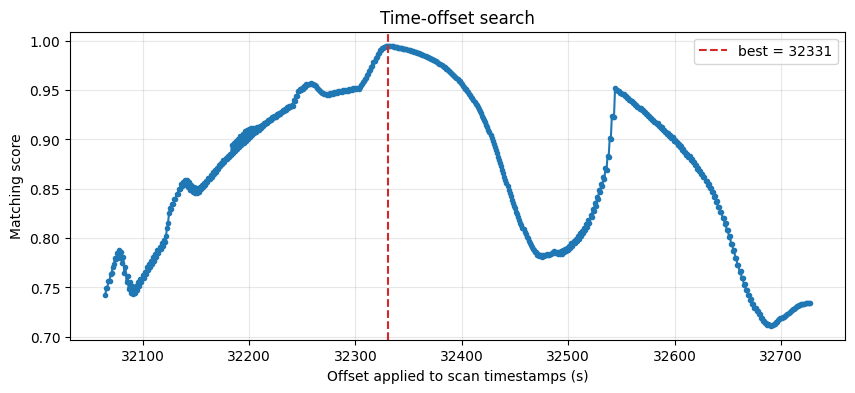

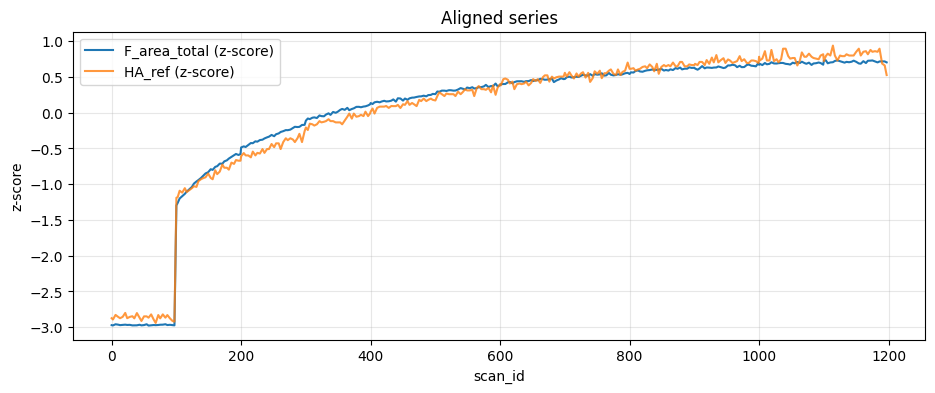

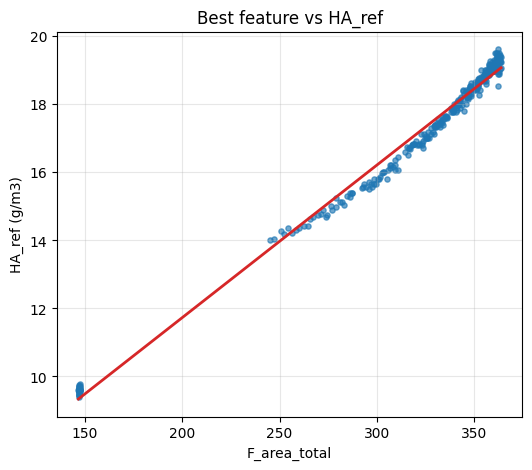

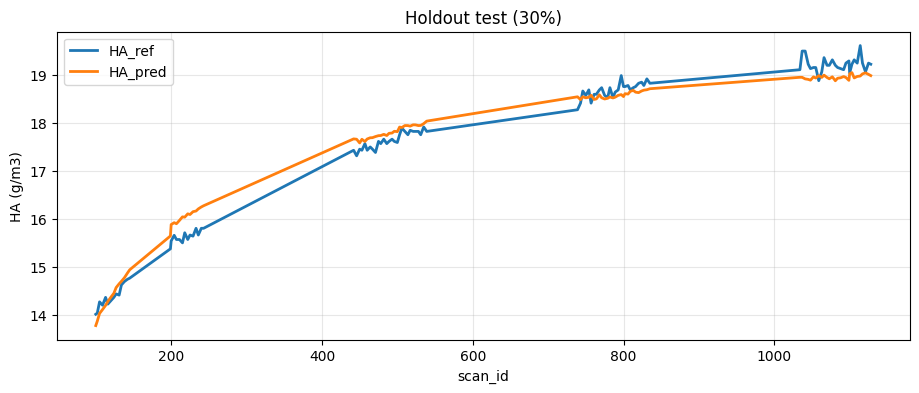

In [23]:
# [Guide] Étape 8: plots de contrôle pour valider matching et calibration.

# Score matching
plt.figure(figsize=(10, 4))
plt.plot(shift_scores[match_axis_col], shift_scores['score'], marker='o', ms=3)
plt.axvline(final_shift, color='tab:red', linestyle='--', label=f'best = {final_shift}')
plt.xlabel(match_axis_label)
plt.ylabel('Matching score')
plt.title(match_title)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Timeline z-score
if not aligned_final.empty:
    a = aligned_final.sort_values('scan_id')
    x = a['scan_id'].to_numpy(dtype=int)
    y1 = _zscore(a[best_feature].to_numpy(dtype=float))
    y2 = _zscore(a['HA_ref'].to_numpy(dtype=float))
    plt.figure(figsize=(11, 4))
    plt.plot(x, y1, label=f'{best_feature} (z-score)')
    plt.plot(x, y2, label='HA_ref (z-score)', alpha=0.8)
    plt.xlabel('scan_id')
    plt.ylabel('z-score')
    plt.title('Aligned series')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # Scatter feature -> HA
    x_feat = a[best_feature].to_numpy(dtype=float)
    y_ha = a['HA_ref'].to_numpy(dtype=float)
    slope, intercept = np.polyfit(x_feat, y_ha, deg=1)
    xx = np.linspace(np.min(x_feat), np.max(x_feat), 200)
    yy = slope * xx + intercept
    plt.figure(figsize=(6, 5))
    plt.scatter(x_feat, y_ha, s=14, alpha=0.65)
    plt.plot(xx, yy, color='tab:red', linewidth=2)
    plt.xlabel(best_feature)
    plt.ylabel('HA_ref (g/m3)')
    plt.title('Best feature vs HA_ref')
    plt.grid(True, alpha=0.3)
    plt.show()

# Holdout predictions
if not calib_pred.empty:
    p = calib_pred.sort_values('scan_id')
    plt.figure(figsize=(11, 4))
    plt.plot(p['scan_id'], p['HA_ref'], label='HA_ref', linewidth=2)
    plt.plot(p['scan_id'], p['HA_pred'], label='HA_pred', linewidth=2)
    plt.xlabel('scan_id')
    plt.ylabel('HA (g/m3)')
    plt.title('Holdout test (30%)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Evite la re-affichage de figures plus tard dans le notebook
plt.close('all')


## 9) Export des resultats

Les CSV/figures sont sauvegardes pour reutilisation dans d'autres notebooks/scripts.


In [24]:
# [Guide] Étape 9: export des CSV finaux pour analyse/reprise.

run_summary = pd.DataFrame([{
    'dataset_name': DATASET_NAME,
    'data_dir': str(DATA_DIR),
    'button_path': str(BUTTON_PATH),
    'summary_path': str(SUMMARY_PATH) if SUMMARY_PATH else '',
    'n_scans': len(df_laser),
    'n_button_rows': len(df_btn),
    'n_summary_rows': len(df_summary),
    'best_match_value': final_shift,
    'summary_validated_shift': summary_shift,
    'summary_corr_absorbance': summary_corr,
    'summary_pairs': summary_n,
    'final_method': final_method,
    'final_pairs': len(aligned_final),
    'best_feature': best_feature,
    'best_corr_HA': float(best_feature_row['corr_HA']),
    'best_corr_Abs': float(best_feature_row['corr_Abs']),
}])

shift_scores.to_csv(OUT_REP_DIR / 'matching_shift_scores.csv', index=False)
corr_final.sort_values('corr_HA', key=lambda s: s.abs(), ascending=False).to_csv(
    OUT_REP_DIR / 'matching_feature_correlations.csv', index=False
)
calib_metrics.to_csv(OUT_REP_DIR / 'calibration_metrics.csv', index=False)
calib_pred.to_csv(OUT_REP_DIR / 'calibration_holdout_predictions.csv', index=False)
df_laser.to_csv(OUT_REP_DIR / 'laser_features_all_scans.csv', index=False)
aligned_final.to_csv(OUT_REP_DIR / 'aligned_laser_button.csv', index=False)
run_summary.to_csv(OUT_REP_DIR / 'laser_matching_run_summary.csv', index=False)

print('Saved reports in', OUT_REP_DIR)
print(run_summary.T)


Saved reports in /Users/valonmehmeti/hesso/PI/outputs/reports
                                                                         0
dataset_name                                           current_calibration
data_dir                 /Users/valonmehmeti/hesso/PI/data/raw/calibration
button_path              /Users/valonmehmeti/hesso/PI/data/raw/calibrat...
summary_path                                                              
n_scans                                                               1200
n_button_rows                                                          543
n_summary_rows                                                           0
best_match_value                                                     32331
summary_validated_shift                                                  0
summary_corr_absorbance                                                NaN
summary_pairs                                                            0
final_method                          

## 10) Notes pour travailler dessus

Pour tester rapidement sur un autre jeu:
1. Modifier `DATASET_NAME` dans la cellule de configuration
2. Relancer les cellules 1 -> 9 pour verifier `I`, `I0`, `A`
3. Relancer ensuite la lecture bouton, le matching et la calibration

Regle pratique:
- lire `test_30_blocked_balanced` comme metrique de validation principale sur un protocole monotone sec -> humide
- garder `test_30_chrono` comme diagnostic de derive temporelle en fin de serie
- si un futur protocole contient de vrais paliers/repetitions, comparer les deux
